# Exploratory CO2 Emissions Prediction Post 1960

In this implements a short term exploratory prediction model for CO2 emissions using post 1960 data. The point is to demonstrate how historical emissions trends can be extended using interpretable machine learning techniques for dashboard integration.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error

In [9]:
df = pd.read_csv("../data/cleaned_co2.csv")
# Using cleaned dataset from EDA (post-1960, no missing CO2)
df_analysis = df.copy()


In [11]:
def predict_co2(country, start_year=2000, forecast_years=5):

    # Filter country data
    country_data = df[df["country"] == country].copy()
    country_data = country_data[country_data["year"] >= start_year]
    country_data = country_data.dropna(subset=["co2"])
    country_data = country_data[country_data["year"] != 2020]

    if len(country_data) < 10:
        print("Not enough data for reliable prediction.")
        return None

    # Ensure sorted by year
    country_data = country_data.sort_values("year")

    X = country_data[["year"]] - country_data["year"].min()
    y = country_data["co2"]

    # Time-based split
    split_index = int(len(country_data) * 0.8)

    X_train = X.iloc[:split_index]
    y_train = y.iloc[:split_index]

    X_test = X.iloc[split_index:]
    y_test = y.iloc[split_index:]

    # Train linear model
    model = LinearRegression()
    model.fit(X_train, y_train)

    y_test_pred = model.predict(X_test)

    # Polynomial optimisation
    best_rmse_poly = float("inf")
    best_degree = None
    best_poly_model = None
    best_r2_poly = None

    for d in [1, 2, 3]:
        poly = PolynomialFeatures(degree=d)
        X_poly = poly.fit_transform(X)

        X_train_poly = X_poly[:split_index]
        X_test_poly = X_poly[split_index:]

        temp_model = LinearRegression()
        temp_model.fit(X_train_poly, y_train)

        temp_pred = temp_model.predict(X_test_poly)
        temp_rmse = np.sqrt(mean_squared_error(y_test, temp_pred))
        temp_r2 = r2_score(y_test, temp_pred)

        if temp_rmse < best_rmse_poly:
            best_rmse_poly = temp_rmse
            best_degree = d
            best_poly_model = temp_model
            best_poly = poly
            best_y_pred_poly = temp_pred
            best_r2_poly = temp_r2

    y_pred_poly = best_y_pred_poly

    # Evaluation
    r2 = r2_score(y_test, y_test_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    r2_poly = best_r2_poly
    rmse_poly = best_rmse_poly

    # Baseline
    last_train_value = y_train.iloc[-1]
    baseline_pred = np.full(len(y_test), last_train_value)
    baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

    # Print results
    print(f"\nEvaluation for {country} (Test Set):")
    print(f"Best Polynomial Degree: {best_degree}")
    print(f"Linear Regression R²: {r2:.4f}")
    print(f"Linear Regression RMSE: {rmse:.2f}")
    print(f"Naive Baseline RMSE: {baseline_rmse:.2f}")

    print("\nPolynomial Regression Results:")
    print(f"Polynomial R²: {r2_poly:.4f}")
    print(f"Polynomial RMSE: {rmse_poly:.2f}")

    # Compare models vs baseline
    best_rmse = min(rmse, rmse_poly)

    if best_rmse < baseline_rmse:
        print("Result: Model outperforms naive baseline.")
    else:
        print("Result: Naive baseline outperforms models.")

    # Future forecast
    last_year = country_data["year"].max()
    future_years = np.arange(last_year + 1, last_year + forecast_years + 1)
    future_df = pd.DataFrame({"year": future_years})

    # Linear future prediction
    future_pred_linear = model.predict(future_df - country_data["year"].min())

    # Polynomial future prediction
    future_poly = best_poly.transform(future_df - country_data["year"].min())
    future_pred_poly = best_poly_model.predict(future_poly)

    # Choose best model
    if rmse_poly < rmse:
        best_model_name = "Polynomial"
        future_pred = future_pred_poly
        best_r2 = r2_poly
    else:
        best_model_name = "Linear"
        future_pred = future_pred_linear
        best_r2 = r2

    # Prevent negative predictions
    future_pred = np.maximum(future_pred, 0)

    print(f"\nBest model selected: {best_model_name}")
    # Warning For Low R2
    if best_r2 < 0.5:
        print("Warning: Model has low explanatory power (R² < 0.5)")

    # Plot
    plt.figure(figsize=(10,6))

    plt.plot(country_data["year"], country_data["co2"], label="Actual")
    plt.plot(X_test["year"] + country_data["year"].min(), y_test_pred, linestyle="--", label="Test Prediction")
    plt.plot(X_test["year"] + country_data["year"].min(), baseline_pred, linestyle=":", label="Naive Baseline")

    plt.plot(future_years, future_pred, linestyle="--", label=f"Forecast ({best_model_name})")

    plt.axvline(X_test["year"].min() + country_data["year"].min(), linestyle=":", label="Train/Test Split")

    plt.title(f"Exploratory CO₂ Forecast for {country}")
    plt.xlabel("Year")
    plt.ylabel("CO₂ emissions (million tonnes)")
    plt.legend()
    plt.show()

    return {
        "best_model": best_model_name,
        "r2_test": best_r2,
        "rmse_test": rmse_poly if best_model_name == "Polynomial" else rmse,
        "baseline_rmse": baseline_rmse,
        "forecast_years": future_years,
        "forecast_values": future_pred
    }


Evaluation for United Kingdom (Test Set):
Best Polynomial Degree: 3
Linear Regression R²: -0.3290
Linear Regression RMSE: 25.66
Naive Baseline RMSE: 56.50

Polynomial Regression Results:
Polynomial R²: 0.7176
Polynomial RMSE: 11.83
Result: Model outperforms naive baseline.

Best model selected: Polynomial


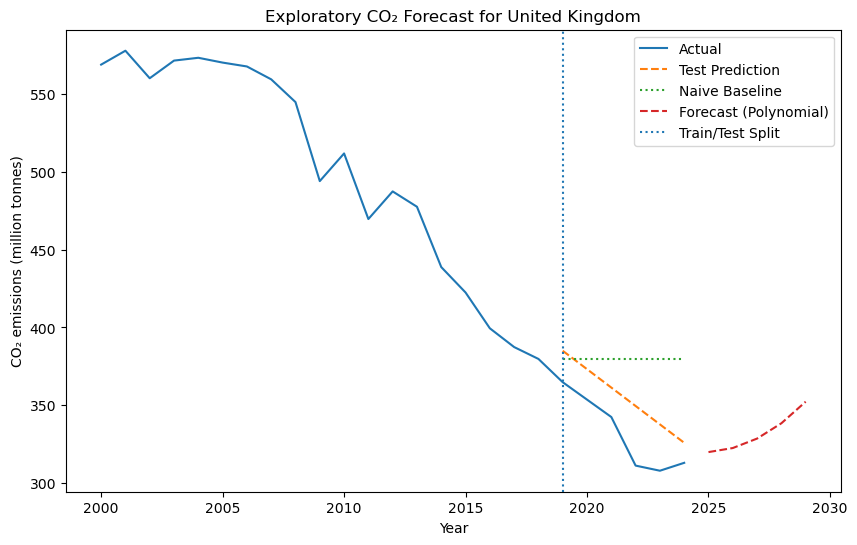


Evaluation for Germany (Test Set):
Best Polynomial Degree: 1
Linear Regression R²: -2.8798
Linear Regression RMSE: 102.60
Naive Baseline RMSE: 125.93

Polynomial Regression Results:
Polynomial R²: -2.8798
Polynomial RMSE: 102.60
Result: Model outperforms naive baseline.

Best model selected: Linear


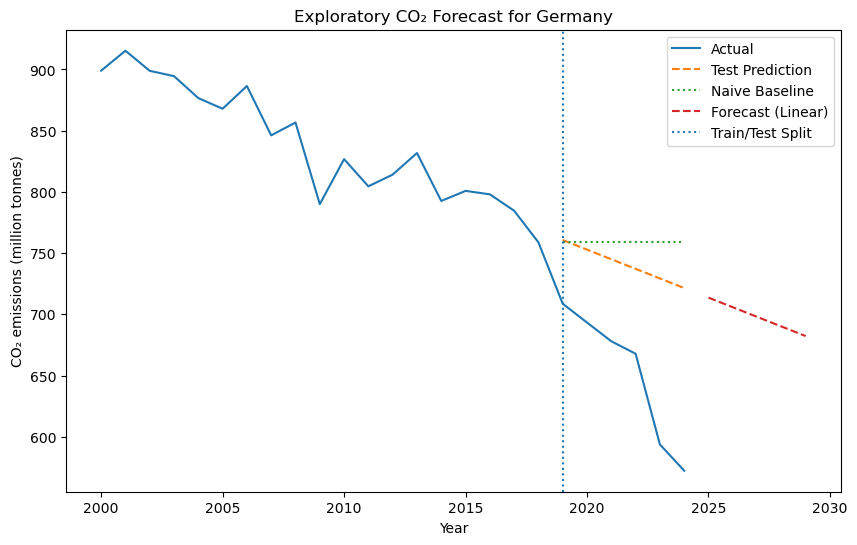

{'best_model': 'Linear',
 'r2_test': -2.8798304275815267,
 'rmse_test': 102.59771209608212,
 'baseline_rmse': 125.93283283242697,
 'forecast_years': array([2025, 2026, 2027, 2028, 2029]),
 'forecast_values': array([713.64225614, 705.80056491, 697.95887368, 690.11718246,
        682.27549123])}

In [13]:
predict_co2("United Kingdom")
predict_co2("Germany")